# Non-LLM workflow

In [13]:
from langgraph.graph import StateGraph, START,END
from typing import TypedDict

In [10]:
# define state
class BMIState(TypedDict):
    weight: float
    height: float
    bmi: float

In [12]:
# calc bmi
def calc_bmi(state: BMIState):
    bmi = state["weight"] / (state["height"]**2)

    return {"bmi": round(bmi, 2)}

In [14]:
# define graph
graph = StateGraph(BMIState)

# add nodes
graph.add_node("calc_bmi", calc_bmi)

# add edges
graph.add_edge(START, "calc_bmi")
graph.add_edge("calc_bmi", END)

# compile graph
workflow = graph.compile()

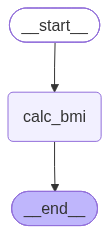

In [15]:
workflow

In [21]:
# invoke
state = {"weight":42, "height":1.73}
response = workflow.invoke(input=state)
response

{'weight': 42, 'height': 1.73, 'bmi': 14.03}

# LLM Workflow : prompt chaining

In [36]:
from langchain_core.prompts import PromptTemplate
from langchain_core.runnables import RunnableSequence
from langchain_deepseek import ChatDeepSeek
from langchain_core.output_parsers import StrOutputParser
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from dotenv import load_dotenv
import os
load_dotenv()

deepseek_api_key = os.getenv("DEEPSEEK_API_KEY")

In [37]:
# state
class BlogState(TypedDict):
    topic: str
    outline: str
    content: str

In [38]:
# create blog outline
def create_blog_outline(state: BlogState):
    outline_prompt = """
    You are an expert blog content strategist.

    The user will provide a topic. Your task is to create a clear, logical, and engaging outline for a blog post on that topic.

    Requirements:
    - Understand the user's topic and identify the target intent.
    - Create a suitable blog title.
    - Organize the blog into logical sections using H2 and H3 headings.
    - Include the key points that should be covered under each section.
    - Ensure the sections flow naturally from introduction to conclusion.
    - Avoid unnecessary or repetitive sections.
    - Make the outline suitable for the intended audience.
    - Do not write the actual blog content; provide only the outline.

    User topic:
    {topic}
    """
    prompt_template = PromptTemplate.from_template(outline_prompt)
    chat_model = ChatDeepSeek(api_key=deepseek_api_key, model="deepseek-v4-flash")

    chain = RunnableSequence(prompt_template, chat_model, StrOutputParser())
    response = chain.invoke({"topic": state["topic"]})
    return {"outline": response}


In [39]:
# create blog content
def create_blog_content(state: BlogState):
    content_prompt = """
    You are an expert blog writer.

    Your task is to write a complete, engaging, and well-structured blog post based on the topic and outline provided by the user.

    Requirements:
    - Follow the provided outline closely.
    - Write a suitable and engaging introduction.
    - Expand every section and subsection from the outline with useful, relevant information.
    - Maintain a logical flow between sections.
    - Use clear and easy-to-understand language.
    - Use appropriate H2 and H3 headings.
    - Include examples, explanations, or practical insights where they add value.
    - Avoid unnecessary repetition and filler content.
    - Keep the content informative and engaging.
    - Write for the intended audience and assume they have a basic understanding of the topic unless specified otherwise.
    - End with a concise conclusion summarizing the key takeaways.
    - Do not mention that the content was generated from an outline.
    - Return only the completed blog post.

    Topic:
    {topic}

    Blog outline:
    {outline}
    """
    prompt_template = PromptTemplate.from_template(content_prompt)
    chat_model = ChatDeepSeek(api_key=deepseek_api_key, model="deepseek-v4-flash")

    chain = RunnableSequence(prompt_template, chat_model, StrOutputParser())
    response = chain.invoke({"topic": state["topic"], "outline": state["outline"]})

    return {"content": response}


In [40]:
# graph
graph = StateGraph(BlogState)

# nodes
graph.add_node("create_outline", create_blog_outline)
graph.add_node("create_content", create_blog_content)

# edges
graph.add_edge(START, "create_outline")
graph.add_edge("create_outline", "create_content")
graph.add_edge("create_content", END)

# compile
workflow = graph.compile()

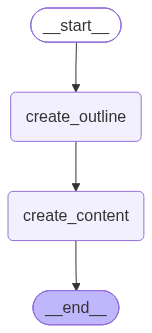

In [41]:
workflow

In [42]:
# invoke
state = {"topic": "AI takeover human jobs and aftermath"}
response = workflow.invoke(input=state)
response

{'topic': 'AI takeover human jobs and aftermath',
 'outline': '# Blog Outline: AI Takeover and the Future of Work\n\n**Blog Title:**  \n**AI Takeover or AI Shift? Jobs at Risk, the New Opportunities, and the Aftermath We Must Prepare For**\n\n## Introduction\n- Hook: AI’s rapid rise in everyday tools—chatbots, automation, generative AI.\n- Define “AI takeover” vs. reality: AI is replacing tasks first, not entire jobs overnight.\n- Purpose of the post: help readers understand what’s being disrupted, what comes next, and how to navigate the “aftermath.”\n\n## H2: The Current State of AI in the Workplace\n- H3: From Assistive Tools to Autonomous Agents  \n  - Key point: AI has moved from simple automation to decision-making and content creation.  \n- H3: Industries Already Feeling the Shift  \n  - Key point: Manufacturing, customer service, logistics, finance, and media are early adopters.  \n- H3: What the Data Says  \n  - Key point: Projections from McKinsey, World Economic Forum, and P

In [43]:
print(response["topic"])

AI takeover human jobs and aftermath


In [44]:
print(response["outline"])

# Blog Outline: AI Takeover and the Future of Work

**Blog Title:**  
**AI Takeover or AI Shift? Jobs at Risk, the New Opportunities, and the Aftermath We Must Prepare For**

## Introduction
- Hook: AI’s rapid rise in everyday tools—chatbots, automation, generative AI.
- Define “AI takeover” vs. reality: AI is replacing tasks first, not entire jobs overnight.
- Purpose of the post: help readers understand what’s being disrupted, what comes next, and how to navigate the “aftermath.”

## H2: The Current State of AI in the Workplace
- H3: From Assistive Tools to Autonomous Agents  
  - Key point: AI has moved from simple automation to decision-making and content creation.  
- H3: Industries Already Feeling the Shift  
  - Key point: Manufacturing, customer service, logistics, finance, and media are early adopters.  
- H3: What the Data Says  
  - Key point: Projections from McKinsey, World Economic Forum, and Pew on job displacement and creation.

## H2: Which Jobs Are Most Vulnerable—and

In [45]:
print(response["content"])

# AI Takeover or AI Shift? Jobs at Risk, the New Opportunities, and the Aftermath We Must Prepare For

Ask anyone what keeps them up at night about artificial intelligence and the answer is often the same: “AI is coming for my job.” And it’s not hard to see why. Chatbots write emails and code. Generative AI produces images, legal drafts, and marketing plans in seconds. Robots pack boxes in warehouses while algorithms take on tasks that used to require a human eye, a human ear, or a human brain.

But are we really facing an AI takeover? Or are we living through an AI shift—a messy, stressful, and transformative transition where some jobs disappear, many more change shape, and new opportunities emerge from beneath the rubble? The truth is more nuanced than clickbait headlines suggest. AI is largely replacing **tasks**, not entire jobs overnight. Still, the cumulative effect of those task-level changes will be enormous.

This post is your map through the disruption. We’ll explore how AI i